In [ ]:
from google.colab import files
import zipfile
import os

# Upload ZIP file
uploaded = files.upload()
zip_file_name = list(uploaded.keys())[0]

# Extract ZIP
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# Check extracted files
os.listdir("dataset")


Saving Huntington_Disease_Dataset_Preprocessed_Scaled (1).csv.zip to Huntington_Disease_Dataset_Preprocessed_Scaled (1).csv (3).zip


['Huntington_Disease_Dataset_Preprocessed_Scaled (1).csv']

In [ ]:
import pandas as pd
import os

# Define the path to the directory where the zip content was extracted
extracted_data_dir = "dataset/Huntington_Disease_Dataset_Preprocessed_Scaled (1).csv"

# List the contents of this directory to find the actual CSV file name
if os.path.isdir(extracted_data_dir):
    files_in_dir = os.listdir(extracted_data_dir)
    print(f"Files found in '{extracted_data_dir}': {files_in_dir}")

    # Assuming the CSV file is the first (or only) item in this directory
    if files_in_dir:
        csv_actual_filename = files_in_dir[0]
        final_csv_path = os.path.join(extracted_data_dir, csv_actual_filename)
        print(f"Attempting to read CSV from: {final_csv_path}")
        df = pd.read_csv(final_csv_path)
        # Check basic info
        print("DataFrame loaded successfully. First 5 rows:")
        print(df.head())
    else:
        print(f"Error: No files found inside the directory '{extracted_data_dir}'.")
else:
    print(f"Error: '{extracted_data_dir}' is not a directory. Please check the extraction path.")

Files found in 'dataset/Huntington_Disease_Dataset_Preprocessed_Scaled (1).csv': ['Huntington_Disease_Dataset_Preprocessed_Scaled.csv']
Attempting to read CSV from: dataset/Huntington_Disease_Dataset_Preprocessed_Scaled (1).csv/Huntington_Disease_Dataset_Preprocessed_Scaled.csv
DataFrame loaded successfully. First 5 rows:
                             Patient_ID  Age  HTT_CAG_Repeat_Length  \
0  b2a49170-8561-4665-9371-2240b55dd87a   31                     67   
1  f5fae45d-8718-41c4-a957-6928f79f3c8e   33                     38   
2  66ab0567-050b-4d56-9ec4-b676309899a6   69                     37   
3  996a48e4-e841-418f-a539-5a7a86cd815d   66                     50   
4  d45c7ca8-7125-4aaa-8018-5bbc60d35a1f   43                     48   

   Motor_Symptoms  Cognitive_Decline  Chorea_Score  Brain_Volume_Loss  \
0               2                  3          8.80               3.20   
1               3                  2          3.24               5.98   
2               3             

In [ ]:
df.shape


(48536, 28)

In [ ]:
df.info

<bound method DataFrame.info of                                  Patient_ID  Age  HTT_CAG_Repeat_Length  \
0      b2a49170-8561-4665-9371-2240b55dd87a   31                     67   
1      f5fae45d-8718-41c4-a957-6928f79f3c8e   33                     38   
2      66ab0567-050b-4d56-9ec4-b676309899a6   69                     37   
3      996a48e4-e841-418f-a539-5a7a86cd815d   66                     50   
4      d45c7ca8-7125-4aaa-8018-5bbc60d35a1f   43                     48   
...                                     ...  ...                    ...   
48531  27f82b73-b9fe-49d6-b6b9-82e667054725   78                     38   
48532  ff5af7cc-8132-4791-8e8b-aac71f2bade1   61                     76   
48533  f594aab8-7acf-43cd-95d8-c197e202c4ea   66                     35   
48534  32052e20-c2ae-4314-95ce-5daf720b26ca   37                     80   
48535  b063b8fb-9e12-40c2-b6bb-da675033dfd2   37                     48   

       Motor_Symptoms  Cognitive_Decline  Chorea_Score  Brain_Volume_Loss  \
0                   2                  3          8.80               3.20   
1                   3                  2          3.24               5.98   
2                   3                  2          1.01               2.82   
3                   1                  3          3.21               6.77   
4                   2                  1          2.31               7.53   
...               ...                ...           ...                ...   
48531               2                  3          0.09               4.71   
48532               1                  0          8.80               6.92   
48533               3                  3          2.73               6.61   
48534               1                  0          9.81               2.95   
48535               3                  0          0.26               5.25   

       Functional_Capacity  HTT_Gene_Expression_Level  \
0                       94                       1.67   
1                       50                       0.18   
2                       69                       0.90   
3                       76                       1.16   
4                       70                       1.85   
...                    ...                        ...   
48531                   89                       0.49   
48532                   78                       2.44   
48533                   24                       0.51   
48534                   19                       1.16   
48535                   50                       1.70   

       Protein_Aggregation_Level  ... Gene_Mutation_Type_Point Mutation  \
0                           0.58  ...                                 0   
1                           0.30  ...                                 1   
2                           1.04  ...                                 0   
3                           1.87  ...                                 0   
4                           2.94  ...                                 0   
...                          ...  ...                               ...   
48531                       1.24  ...                                 0   
48532                       3.34  ...                                 0   
48533                       0.27  ...                                 0   
48534                       3.22  ...                                 0   
48535                       4.59  ...                                 1   

      Category_Primary Cause  Category_Trans-acting Modifier  \
0                          1                               0   
1                          1                               0   
2                          0                               1   
3                          0                               1   
4                          0                               0   
...                      ...                             ...   
48531                      0                               1   
48532                      0                

In [ ]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers_count} outliers")


Age: 0 outliers
HTT_CAG_Repeat_Length: 0 outliers
Motor_Symptoms: 0 outliers
Cognitive_Decline: 0 outliers
Chorea_Score: 0 outliers
Brain_Volume_Loss: 0 outliers
Functional_Capacity: 0 outliers
HTT_Gene_Expression_Level: 0 outliers
Protein_Aggregation_Level: 0 outliers
Disease_Stage: 0 outliers
Sex_Male: 0 outliers
Family_History_Yes: 0 outliers
Gene_Mutation_Type_Duplication: 0 outliers
Gene_Mutation_Type_Insertion: 0 outliers
Gene_Mutation_Type_Point Mutation: 12133 outliers
Category_Primary Cause: 0 outliers
Category_Trans-acting Modifier: 0 outliers
Gene/Factor_HTT (Somatic Expansion): 12028 outliers
Gene/Factor_MLH1: 0 outliers
Gene/Factor_MSH3: 12056 outliers
Function_CAG Trinucleotide Repeat Expansion: 0 outliers
Function_Mismatch Repair: 0 outliers
Effect_Faster Disease Onset: 12028 outliers
Effect_Neurodegeneration: 0 outliers


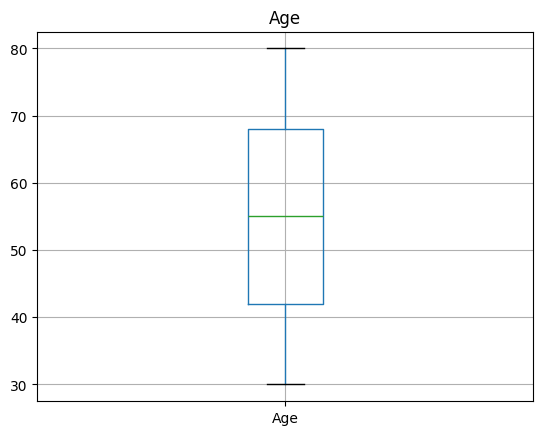

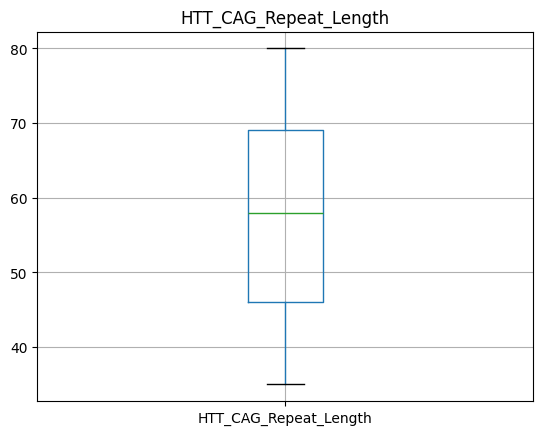

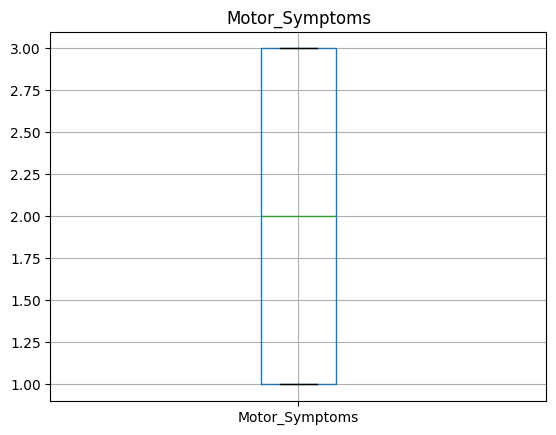

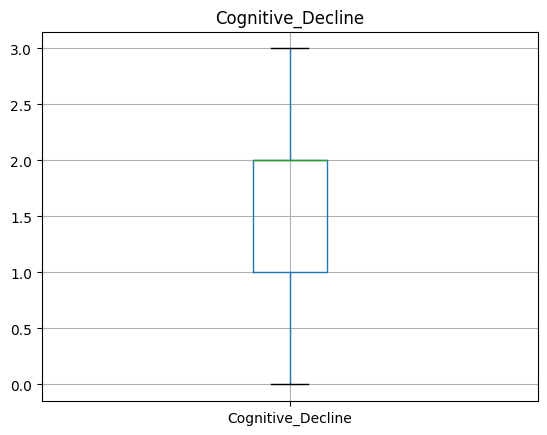

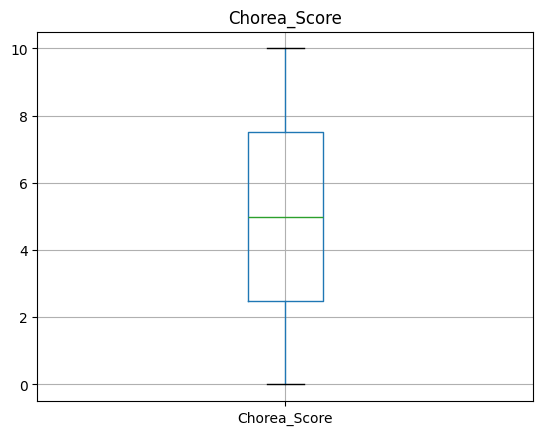

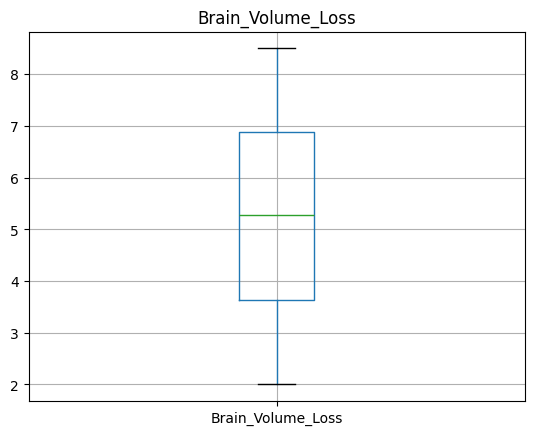

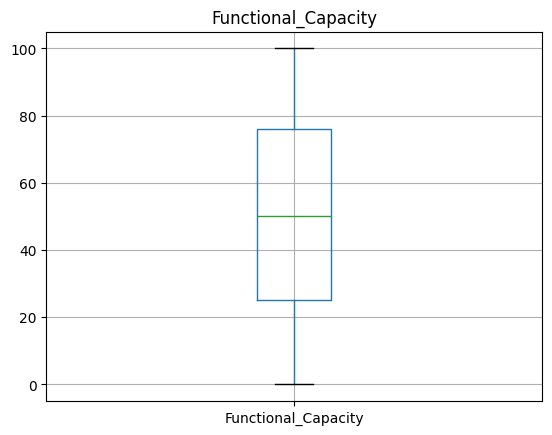

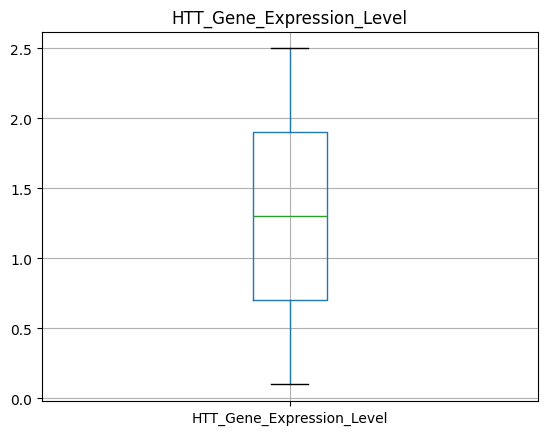

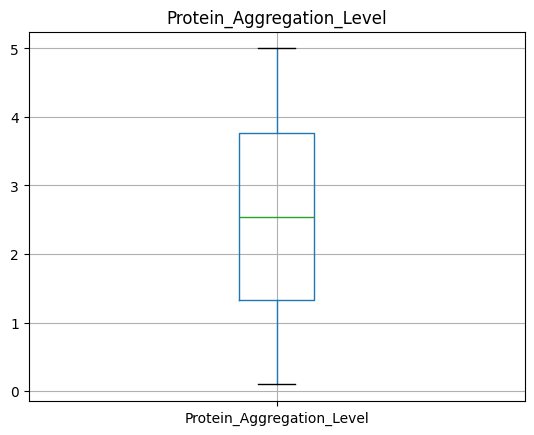

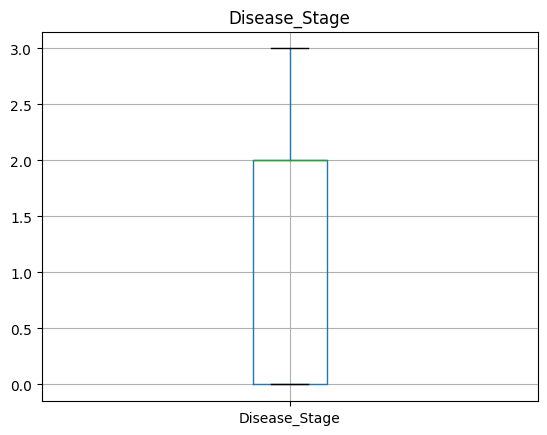

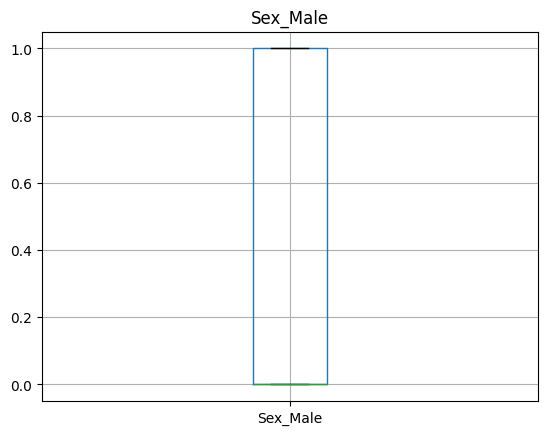

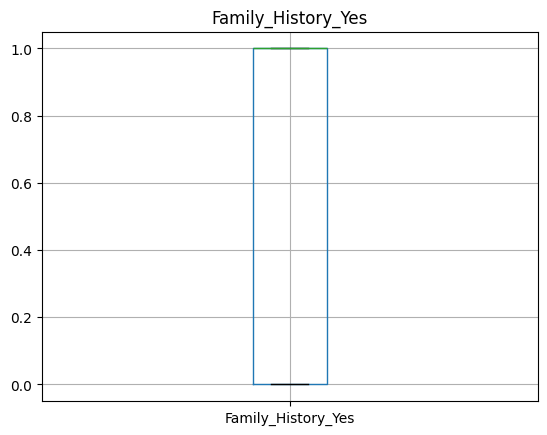

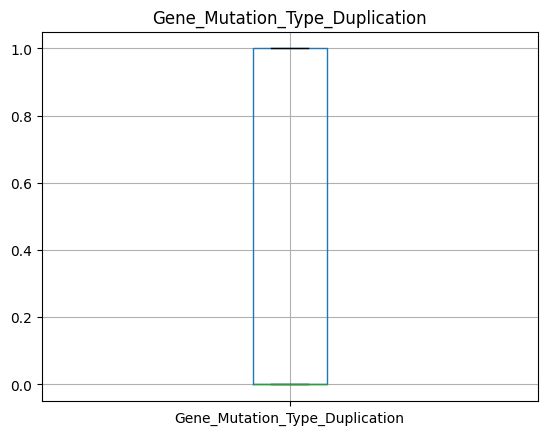

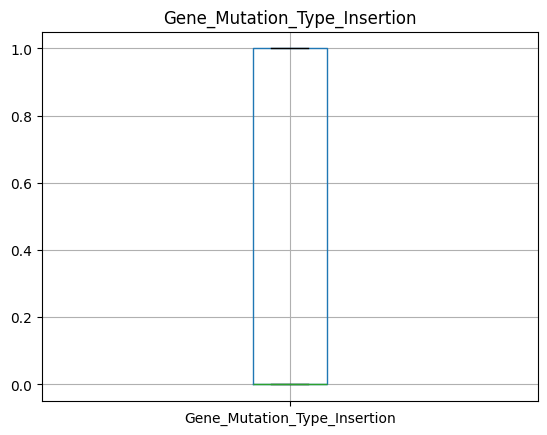

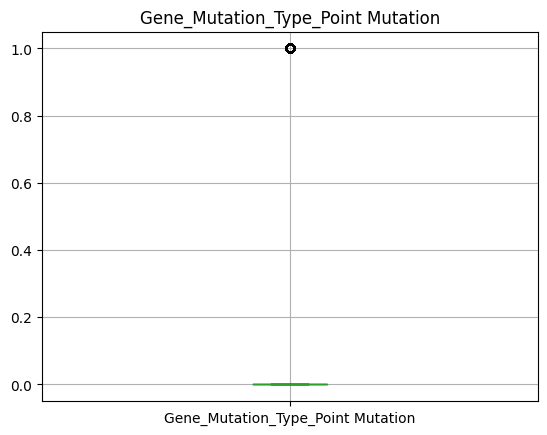

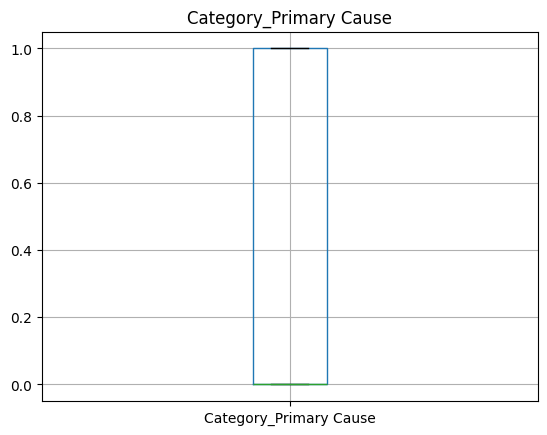

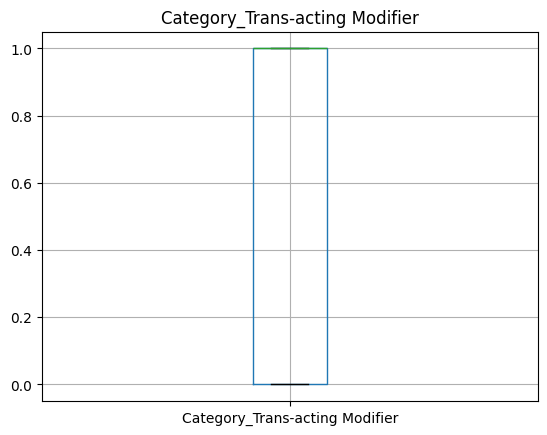

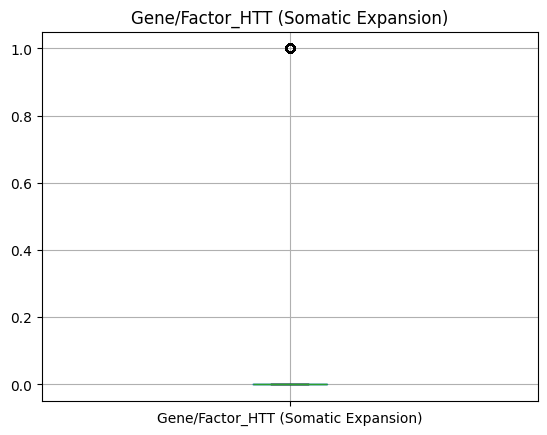

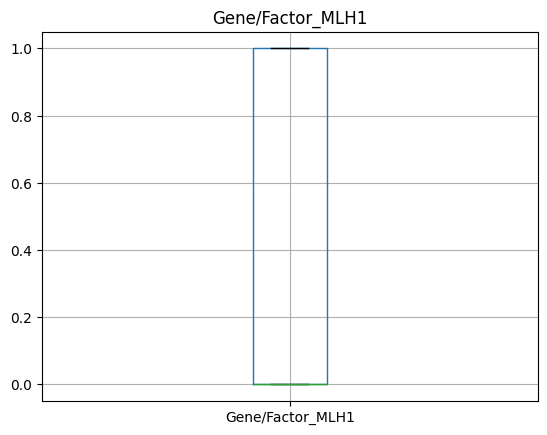

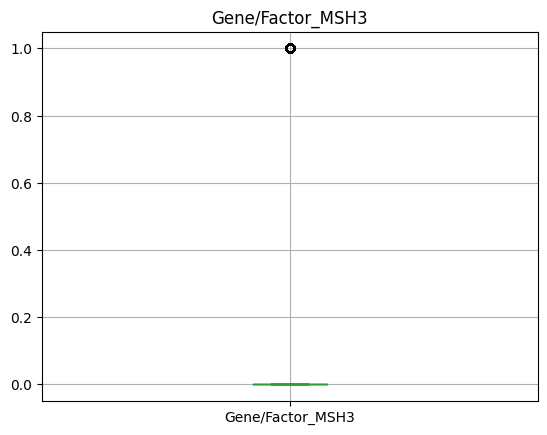

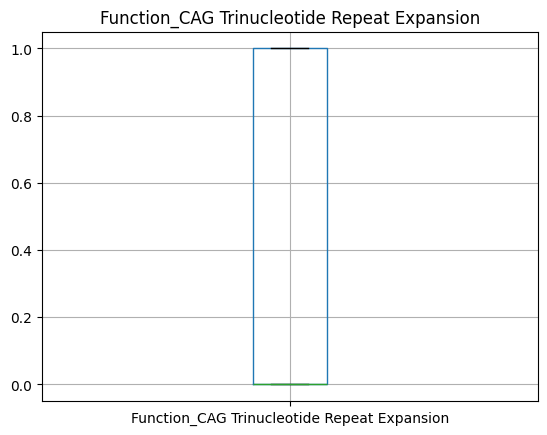

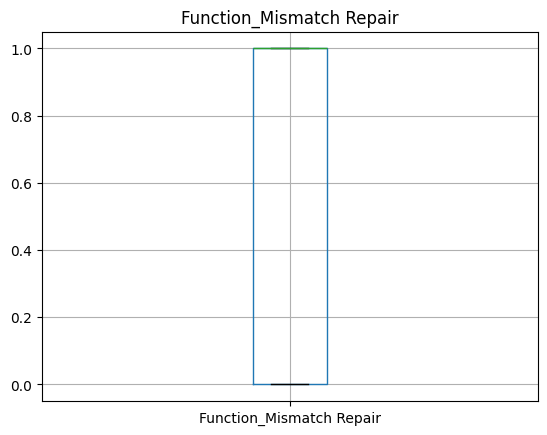

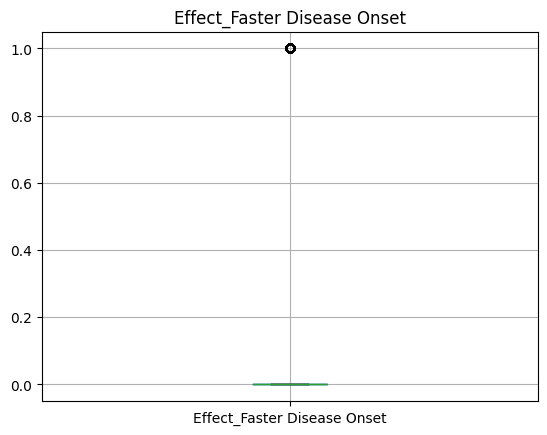

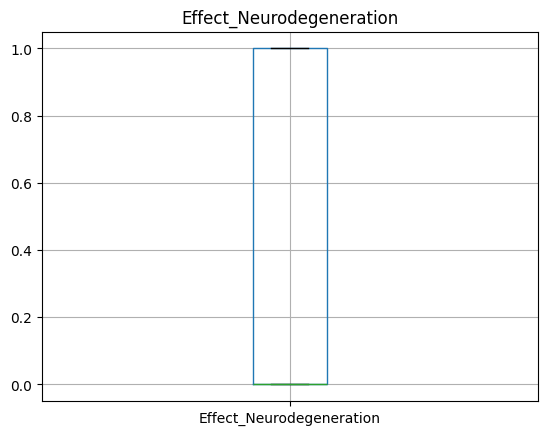

In [ ]:
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(col)
    plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

target_col = 'Motor_Symptoms'

# Separate target
y = df[target_col]

# Encode target if categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Drop target from features
X = df.drop(columns=[target_col], errors='ignore')

# --------------------------------
# FIX: HANDLE STRING COLUMNS
# --------------------------------
# Option 1 (RECOMMENDED for this test): Drop text-heavy columns
non_numeric_cols = X.select_dtypes(include=['object']).columns
X = X.drop(columns=non_numeric_cols)

# --------------------------------

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
# 1. BASELINE MODEL
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_train = accuracy_score(y_train, dummy.predict(X_train))
dummy_test  = accuracy_score(y_test, dummy.predict(X_test))

# 2. COMPLEX MODEL
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

tree_train = accuracy_score(y_train, tree.predict(X_train))
tree_test  = accuracy_score(y_test, tree.predict(X_test))

# 3. RESULTS
print("Baseline (Dummy) Train Accuracy:", round(dummy_train, 3))
print("Baseline (Dummy) Test Accuracy :", round(dummy_test, 3))

print("\nComplex Model (Tree) Train Accuracy:", round(tree_train, 3))
print("Complex Model (Tree) Test Accuracy :", round(tree_test, 3))

print("\n----------------------------------")

if tree_train < 0.6 and tree_test < 0.6:
    print("🔴 UNDERFITTING DETECTED")
    print("Next steps:")
    print("- Add informative features")
    print("- Use richer representations (e.g., embeddings)")
    print("- Try more expressive models")

elif tree_train - tree_test > 0.2:
    print("🔵 OVERFITTING DETECTED")
    print("Next steps:")
    print("- Feature selection")
    print("- Regularization")
    print("- Limit model complexity")
    print("- Increase dataset size")

else:
    print("🟢 GOOD FIT (No major overfitting or underfitting)")
    print("Next steps:")
    print("- Proceed to final modeling")
    print("- Hyperparameter tuning")
    print("- Report results")


Baseline (Dummy) Train Accuracy: 0.335
Baseline (Dummy) Test Accuracy : 0.335

Complex Model (Tree) Train Accuracy: 1.0
Complex Model (Tree) Test Accuracy : 0.338

----------------------------------
🔵 OVERFITTING DETECTED
Next steps:
- Feature selection
- Regularization
- Limit model complexity
- Increase dataset size


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

tree.fit(X_train, y_train)

print("Train Accuracy:", accuracy_score(y_train, tree.predict(X_train)))
print("Test Accuracy :", accuracy_score(y_test, tree.predict(X_test)))


Train Accuracy: 0.35281824871228845
Test Accuracy : 0.33047180825492756


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
df['Motor_Symptoms'].value_counts(normalize=True)


,proportion
Motor_Symptoms,
2,0.335030
3,0.332887
1,0.332083


In [ ]:
# ===============================
# 1. IMPORTS
# ===============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# ===============================
# 2. TARGET & FEATURES
# ===============================
target_col = 'Motor_Symptoms'

y = df[target_col]
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

X = df.drop(columns=[target_col], errors='ignore')

# use only numeric features
X = X.select_dtypes(include=np.number)

# ===============================
# 3. SCALE FEATURES (IMPORTANT)
# ===============================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ===============================
# 4. TRAIN / TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ===============================
# 5. EPOCH-BASED MODEL
# ===============================
# max_iter = epochs
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=100,        # 👈 EPOCHS
    random_state=42
)

# ===============================
# 6. TRAIN MODEL
# ===============================
model.fit(X_train, y_train)

# ===============================
# 7. ACCURACY CHECK
# ===============================
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, model.predict(X_test))

print("Train Accuracy:", round(train_acc, 3))
print("Test Accuracy :", round(test_acc, 3))


Train Accuracy: 0.467
Test Accuracy : 0.332


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# =========================================
# 2. PREPARE DATA
# =========================================
target_col = 'Motor_Symptoms'

# Target
y = df[target_col]
# The target column 'Motor_Symptoms' has values 1, 2, 3.
# For sparse_categorical_crossentropy, labels should be 0-indexed (0, 1, 2).
# We subtract 1 to transform 1->0, 2->1, 3->2.
y = y - 1

# Features (numeric only)
X = df.drop(columns=[target_col], errors='ignore')
X = X.select_dtypes(include=np.number)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================================
# 3. BUILD NEURAL NETWORK
# =========================================
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')   # 3 classes
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================
# 4. TRAIN MODEL WITH EPOCHS (Like MNIST)
# =========================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,  # same as MNIST style
    epochs=400,             # number of epochs
    batch_size=32,
    callbacks=[early_stop],
    verbose=1              # displays per epoch results automatically
)

# =========================================
# 5. EVALUATE ON TEST DATA
# =========================================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("\nTest accuracy:", round(test_acc, 4))

Epoch 1/400


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


850/850 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3363 - loss: 1.1571 - val_accuracy: 0.3238 - val_loss: 1.1003
Epoch 2/400
850/850 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3355 - loss: 1.1009 - val_accuracy: 0.3247 - val_loss: 1.0994
Epoch 3/400
850/850 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3375 - loss: 1.0991 - val_accuracy: 0.3188 - val_loss: 1.0989
Epoch 4/400
850/850 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3320 - loss: 1.0986 - val_accuracy: 0.3158 - val_loss: 1.0999
Epoch 5/400
850/850 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3393 - loss: 1.0989 - val_accuracy: 0.3403 - val_loss: 1.0989
Epoch 6/400
850/850 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3397 - loss: 1.0986 - val_accuracy: 0.3249 - val_loss: 1.0994
Epoch 7/400
850/850 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3445 - loss: 1.0977 - val_accuracy: 0.3161 - val_loss: 1.0998
Epoch 8/400
850/850 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3418 - loss: 1.0980 - val_accuracy: 0.3148